# Security Data — Linear Regression

## Dataset
Data sourced from `security_data_10000.csv` (synthetic data generated from original class dataset).

| Column | Description |
|--------|-------------|
| Sector | Industry sector of the company |
| CEO_Gender | Gender of the CEO (Male/Female) |
| Size | Company size (Large, Medium, Small) |
| Security_Invest | Security investment amount |
| Security_Breach_Att | Number of security breach attempts |
| Succ_Sec_Breaches | Number of successful security breaches |
| Sec_Rating | Overall security rating (High/Medium/Low) |
| CEO_Sec_Exp | CEO's level of security experience (High/Medium/Low) |
| LOT_in_Business | Length of time in business (years) |
| Stock_Market | Whether the company is listed on the stock market (Yes/No) |

---

## Data Analysis Plan

1. **EDA** — Understand structure, summary statistics, and distributions
2. **Data Cleaning** — Check and handle missing/null values
3. **Outlier Detection** — Identify outliers using Isolation Forest
4. **Data Types** — Evaluate and encode categorical features
5. **Feature Scaling** — Apply standardization/normalization
6. **Correlation Analysis** — Understand feature relationships
7. **Train-Test Split** — Split dataset before any feature engineering
8. **Feature Engineering** — Apply transformations to both train and test sets
9. **Modelling** — Fit model, predict, and evaluate using MSE and R²

In [341]:
#LOAD THE DATASET


import pandas as pd

security_df = pd.read_csv("security_data_10000.csv")

security_df.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Hospitality,Male,Large,186,80,38,High,High,11,No
1,Hospitality,Female,Large,229,72,42,Medium,Medium,21,Yes
2,Hospitality,Male,Small,108,78,35,High,Medium,15,Yes
3,Hospitality,Male,Large,210,70,35,Medium,Low,14,No
4,Banking,Male,Small,34,19,3,Low,High,3,No


## Step 1 — Load Dataset

In [342]:
from sklearn.model_selection import train_test_split
security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)


## Step 2 — Train-Test Split
Split is performed **before** any feature engineering to prevent data leakage.

In [343]:
security_df_train.head()


,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
9254,Hospitality,Male,Large,123,78,26,High,Medium,16,Yes
1561,Hospitality,Male,Medium,419,250,90,Low,High,15,Yes
1670,Banking,Male,Small,28,8,0,Medium,High,15,Yes
6087,Health Care,Male,Large,86,49,26,High,Medium,18,No
6669,Health Care,Male,Medium,125,16,5,Medium,High,10,Yes


## Step 3 — Exploratory Data Analysis (EDA)

In [344]:
security_df_train.shape

(8000, 10)

In [345]:
security_df_train.describe()


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
count,8000.000000,8000.000000,8000.000000,8000.000000
mean,80.993500,60.310875,24.949625,13.022375
std,82.579267,73.817377,36.353106,7.190295
min,10.000000,5.000000,0.000000,1.000000
25%,28.000000,17.000000,2.000000,7.000000
50%,50.000000,32.000000,12.000000,13.000000
75%,99.000000,59.000000,26.000000,19.000000
max,450.000000,330.000000,211.000000,25.000000


In [346]:
security_df_train.isnull().sum()

Sector                 0
CEO_Gender             0
Size                   0
Security_Invest        0
Security_Breach_Att    0
Succ_Sec_Breaches      0
Sec_Rating             0
CEO_Sec_Exp            0
LOT_in_Business        0
Stock_Market           0
dtype: int64

## Step 4 — Missing Value Check

There are no missing values within the dataset (within each column)

array([[<Axes: title={'center': 'Security_Invest'}>,
        <Axes: title={'center': 'Security_Breach_Att'}>],
       [<Axes: title={'center': 'Succ_Sec_Breaches'}>,
        <Axes: title={'center': 'LOT_in_Business'}>]], dtype=object)

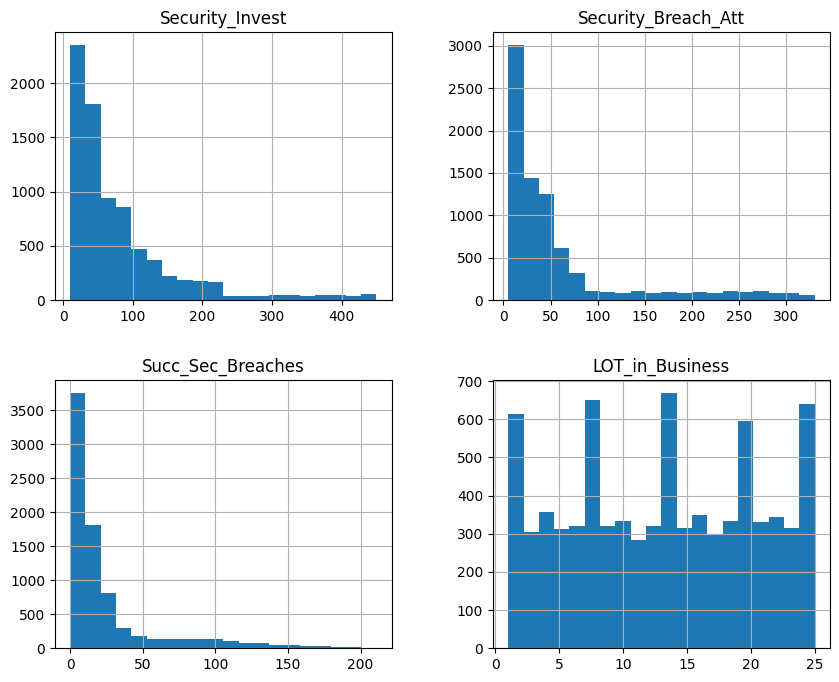

In [347]:
import matplotlib.pyplot as plt


security_df_train.hist(figsize=(10, 8), bins=20)

## Step 5 — Distribution & Outlier Check
Histograms show the distribution of each numeric feature.

No outliers that i can see. mostly independent variables left skewed.

In [348]:
security_df_train.head()


,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
9254,Hospitality,Male,Large,123,78,26,High,Medium,16,Yes
1561,Hospitality,Male,Medium,419,250,90,Low,High,15,Yes
1670,Banking,Male,Small,28,8,0,Medium,High,15,Yes
6087,Health Care,Male,Large,86,49,26,High,Medium,18,No
6669,Health Care,Male,Medium,125,16,5,Medium,High,10,Yes


LOT_in_Business        1.000000
Security_Invest       -0.002782
Security_Breach_Att   -0.003495
Succ_Sec_Breaches     -0.009815
Name: LOT_in_Business, dtype: float64

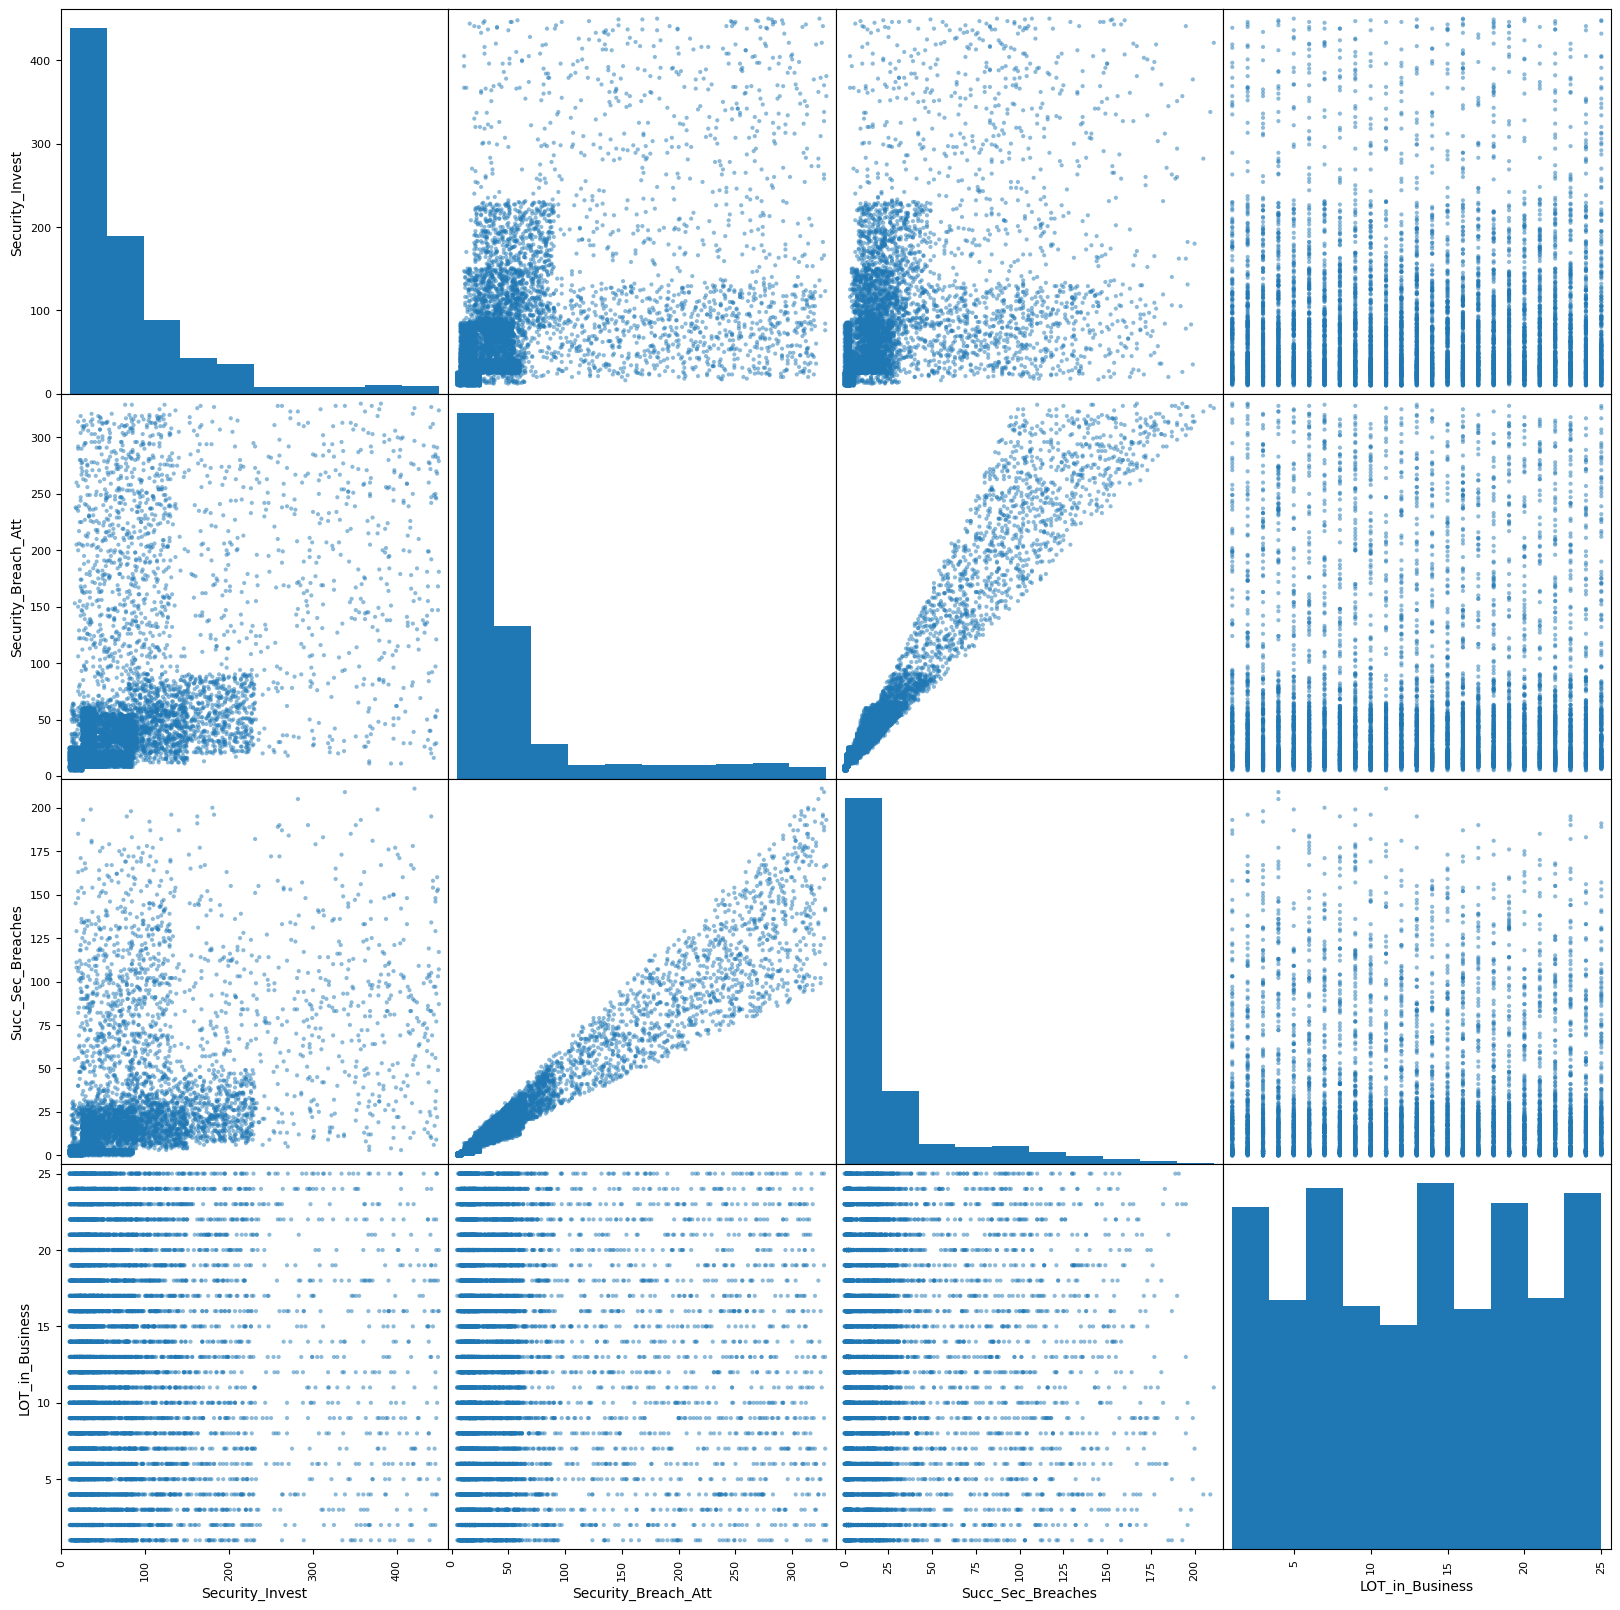

In [349]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

attributes = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches",
              "LOT_in_Business"]
scatter_matrix(security_df_train[attributes], figsize=(20, 20))
#save_fig("scatter_matrix_plot")  # extra code

corr=security_df_train[attributes].corr()
corr["Security_Breach_Att"].sort_values(ascending=False)


corr["LOT_in_Business"].sort_values(ascending=False)


## Step 6 — Correlation Analysis
Scatter matrix and correlation coefficients to understand feature relationships.

No clear correlation between security investment and security breach attempts or successful breaches. There is a positive correlation between breach attempts and successful breaches, which is expected. No meaningful correlation found between length of time in business and breach attempts.

In [350]:
security_df_train_corr =  security_df_train[["Succ_Sec_Breaches","Security_Invest"]]

security_df_train_corr.corr()

,Succ_Sec_Breaches,Security_Invest
Succ_Sec_Breaches,1.000000,0.472491
Security_Invest,0.472491,1.000000


In [351]:
security_df_train.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
9254,Hospitality,Male,Large,123,78,26,High,Medium,16,Yes
1561,Hospitality,Male,Medium,419,250,90,Low,High,15,Yes
1670,Banking,Male,Small,28,8,0,Medium,High,15,Yes
6087,Health Care,Male,Large,86,49,26,High,Medium,18,No
6669,Health Care,Male,Medium,125,16,5,Medium,High,10,Yes


## Step 7 — Simple Linear Regression
**Question:** Can `Security_Invest` alone predict `Succ_Sec_Breaches`?

Simple linear regression uses **one independent variable** and **one dependent variable**.

In [352]:
type(security_df_train["Succ_Sec_Breaches"])

pandas.Series

In [353]:
#simple linear regression

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(security_df_train[["Security_Invest"]], security_df_train["Succ_Sec_Breaches"])

security_df_train["Succ_Sec_Breaches_predicted"] = lin_reg.predict(security_df_train[["Security_Invest"]])

security_df_test["Succ_Sec_Breaches_predicted"] = lin_reg.predict(security_df_test[["Security_Invest"]])

In [354]:
security_df_test.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market,Succ_Sec_Breaches_predicted
6252,Health Care,Male,Large,42,32,14,High,Low,8,Yes,16.838969
4684,Banking,Male,Medium,22,11,1,Low,Low,12,No,12.678964
1731,Banking,Male,Medium,16,22,5,High,High,25,No,11.430963
4742,Hospitality,Female,Medium,285,283,126,High,Medium,14,Yes,67.383021
4521,Health Care,Male,Small,37,59,14,High,Medium,7,Yes,15.798968


In [355]:
lin_reg.coef_, lin_reg.intercept_

(array([0.20800022]), np.float64(8.1029595700448))

In [356]:
security_df_test.head(100)

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market,Succ_Sec_Breaches_predicted
6252,Health Care,Male,Large,42,32,14,High,Low,8,Yes,16.838969
4684,Banking,Male,Medium,22,11,1,Low,Low,12,No,12.678964
1731,Banking,Male,Medium,16,22,5,High,High,25,No,11.430963
4742,Hospitality,Female,Medium,285,283,126,High,Medium,14,Yes,67.383021
4521,Health Care,Male,Small,37,59,14,High,Medium,7,Yes,15.798968
...,...,...,...,...,...,...,...,...,...,...,...
3787,Banking,Female,Large,64,10,1,Medium,Low,23,No,21.414973
9189,Health Care,Female,Small,36,28,13,Medium,Low,10,Yes,15.590967
7825,Health Care,Female,Large,67,29,13,High,High,18,No,22.038974
7539,Hospitality,Male,Medium,122,77,37,Low,Low,12,Yes,33.478986


In [357]:
from sklearn.metrics import mean_squared_error,r2_score


print(r2_score(security_df_test["Succ_Sec_Breaches"], security_df_test["Succ_Sec_Breaches_predicted"]))        # closer to 1 = better
print(mean_squared_error(security_df_test["Succ_Sec_Breaches"], security_df_test["Succ_Sec_Breaches_predicted"]))  # closer to 0 = better


0.20692710404513448
1063.0775768614358


### Evaluation — Simple Linear Regression (Security_Invest → Succ_Sec_Breaches)
- **R²**: closer to 1 = better fit
- **MSE**: closer to 0 = better fit

really bad predictions with simple linear regression. mean squared error should be close to 0


## Step 8 — Simple Linear Regression (Stronger Feature)
**Question:** Can `Security_Breach_Att` (attempts) predict `Succ_Sec_Breaches` (successes)?

Intuitively, more attempts should lead to more successful breaches — a stronger correlation is expected.

In [358]:
#simple linear regression

from sklearn.linear_model import LinearRegression

lin_reg_breach = LinearRegression()

lin_reg_breach.fit(security_df_train[["Security_Breach_Att"]], security_df_train["Succ_Sec_Breaches"])

security_df_train["Succ_Sec_Breaches_predicted"] = lin_reg_breach.predict(security_df_train[["Security_Breach_Att"]])

security_df_test["Succ_Sec_Breaches_predicted"] = lin_reg_breach.predict(security_df_test[["Security_Breach_Att"]])

In [359]:
from sklearn.metrics import mean_squared_error,r2_score


print(r2_score(security_df_test["Succ_Sec_Breaches"], security_df_test["Succ_Sec_Breaches_predicted"]))        # closer to 1 = better
print(mean_squared_error(security_df_test["Succ_Sec_Breaches"], security_df_test["Succ_Sec_Breaches_predicted"]))  # closer to 0 = better


0.9398914861518938
80.57268578501947


Now we get a good score as compared to the previous attempt. 

## Step 9 — Multiple Linear Regression
Using **all features** (numeric + encoded categorical) to predict `Succ_Sec_Breaches`.

Steps:
1. Separate labels from features
2. Impute missing values (fit on train only)
3. Detect outliers using Isolation Forest
4. One-hot encode categorical features
5. Concatenate numeric and categorical features
6. Fit and evaluate

In [360]:
security_df_train=security_df_train.drop("Succ_Sec_Breaches_predicted", axis=1)
security_df_test=security_df_test.drop("Succ_Sec_Breaches_predicted", axis=1)

### 9a — Impute Numeric Features
Fit `SimpleImputer` on train only, then transform both train and test to avoid data leakage. No missing values were found, but imputer is included as part of the pipeline for completeness.

In [361]:
security_df_train.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
9254,Hospitality,Male,Large,123,78,26,High,Medium,16,Yes
1561,Hospitality,Male,Medium,419,250,90,Low,High,15,Yes
1670,Banking,Male,Small,28,8,0,Medium,High,15,Yes
6087,Health Care,Male,Large,86,49,26,High,Medium,18,No
6669,Health Care,Male,Medium,125,16,5,Medium,High,10,Yes


In [362]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy="median")

security_df_train_num = security_df_train.select_dtypes(include=[np.number]).drop("Succ_Sec_Breaches", axis=1)

security_df_test_num = security_df_test.select_dtypes(include=[np.number]).drop("Succ_Sec_Breaches", axis=1)

imputer.fit(security_df_train_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [363]:
security_df_train_num.head()

,Security_Invest,Security_Breach_Att,LOT_in_Business
9254,123,78,16
1561,419,250,15
1670,28,8,15
6087,86,49,18
6669,125,16,10


In [364]:
security_df_test_num.head()

,Security_Invest,Security_Breach_Att,LOT_in_Business
6252,42,32,8
4684,22,11,12
1731,16,22,25
4742,285,283,14
4521,37,59,7


In [365]:
imputer.statistics_

array([50., 32., 13.])

In [366]:
security_df_train_tf=imputer.transform(security_df_train_num)

security_df_test_tf=imputer.transform(security_df_test_num)

In [367]:
security_df_train_tf = pd.DataFrame(security_df_train_tf, columns=security_df_train_num.columns,
                          index=security_df_train_num.index)

security_df_test_tf = pd.DataFrame(security_df_test_tf, columns=security_df_test_num.columns,
                          index=security_df_test_num.index)

In [368]:
security_df_train_labels = security_df_train["Succ_Sec_Breaches"].copy()

security_df_test_labels = security_df_test["Succ_Sec_Breaches"].copy()

In [369]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(security_df_train_tf)

### 9b — Outlier Detection (Isolation Forest)
Isolation Forest assigns `-1` to outliers and `1` to normal points. Outlier removal is optional and commented out below.

In [370]:
outlier_pred

array([ 1, -1,  1, ...,  1,  1,  1], shape=(8000,))

In [371]:
import numpy as np
print("Normal:", (outlier_pred == 1).sum())
print("Outliers:", (outlier_pred == -1).sum())

Normal: 5924
Outliers: 2076


In [372]:
#security_df_train = security_df_train.iloc[outlier_pred == 1]
#security_df_train_labels = security_df_train_labels.iloc[outlier_pred == 1]

In [373]:
from sklearn.preprocessing import OneHotEncoder

sector = OneHotEncoder()

security_df_train_cat = pd.get_dummies(security_df_train[["Sector", "CEO_Gender", "Size", "Sec_Rating", "CEO_Sec_Exp", "Stock_Market"]],dtype=int)

security_df_test_cat = pd.get_dummies(security_df_test[["Sector", "CEO_Gender", "Size", "Sec_Rating", "CEO_Sec_Exp", "Stock_Market"]],dtype=int)

security_df_train_final = pd.concat([security_df_train_tf, security_df_train_cat], axis=1)

security_df_train_final.head()

security_df_test_final = pd.concat([security_df_test_tf, security_df_test_cat], axis=1)




### 9c — Encode Categorical Features
One-hot encode all categorical columns. `dtype=int` ensures 0/1 output instead of True/False.

### 9d — Fit Multiple Linear Regression

In [374]:
from sklearn.linear_model import LinearRegression

mul_lin_reg= LinearRegression()

mul_lin_reg.fit(security_df_train_final, security_df_train_labels)

security_df_train_labels_predicted= mul_lin_reg.predict(security_df_train_final)

security_df_test_labels_predicted = mul_lin_reg.predict(security_df_test_final)


In [375]:
from sklearn.metrics import mean_squared_error,r2_score


print(r2_score(security_df_test_labels, security_df_test_labels_predicted))        # closer to 1 = better
print(mean_squared_error(security_df_test_labels, security_df_test_labels_predicted))  # closer to 0 = better


0.9416509647718834
78.21418598327548


### 9e — Evaluation — Multiple Linear Regression

In [378]:
import plotly.express as px
import pandas as pd

plot_df = pd.DataFrame({"Actual": security_df_test_labels, "Predicted": security_df_test_labels_predicted})

fig = px.scatter(plot_df, x="Actual", y="Predicted", opacity=0.3,
                 title="Actual vs Predicted — Succ_Sec_Breaches")

fig.add_shape(type="line", x0=0, y0=0, x1=60, y1=60,
              line=dict(color="red", dash="dash"))

fig.show()


### 9f — Actual vs Predicted Plot
Points on or near the red dashed line indicate accurate predictions.

Our prediction got better after using multiple linear regression with all the features. The R2 score is closer to 1 and the mean squared error is closer to 0, indicating a better fit of the model to the data.

In [54]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
std_scaler.fit(security_df_train[["Security_Invest"]])

std_scaler.transform(security_df_train[["Security_Invest"]])

array([[ 0.50871274],
       [ 4.0933716 ],
       [-0.64176898],
       ...,
       [ 1.22322245],
       [-0.60543798],
       [ 0.58137475]], shape=(8000, 1))

transform categorical variables to numerical valuses 0 and 1